In [1]:
from pathlib import Path
import matplotlib
import matplotlib.pyplot as plt
import pandas as pd
from math import pi
import numpy as np


plt.style.use('ggplot')

base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')

col_width_inch = 3.25
twocol_width_inch = 6.875

# dpi=250
# matplotlib.rcParams['figure.dpi'] = dpi
# matplotlib.rcParams['font.size'] = 4

In [ ]:
# output = base_datadir / 'multiorg_for_orgasegment'
# output.mkdir()

# for file in base_datadir.glob('MultiOrg/test/Macros/Plate_*/image_*/*.tiff'):
    

In [3]:
matplotlib.rcParams.keys()

KeysView(RcParams({'_internal.classic_mode': False,
          'agg.path.chunksize': 0,
          'animation.bitrate': -1,
          'animation.codec': 'h264',
          'animation.convert_args': ['-layers', 'OptimizePlus'],
          'animation.convert_path': 'convert',
          'animation.embed_limit': 20.0,
          'animation.ffmpeg_args': [],
          'animation.ffmpeg_path': 'ffmpeg',
          'animation.frame_format': 'png',
          'animation.html': 'none',
          'animation.writer': 'ffmpeg',
          'axes.autolimit_mode': 'data',
          'axes.axisbelow': True,
          'axes.edgecolor': 'white',
          'axes.facecolor': '#E5E5E5',
          'axes.formatter.limits': [-5, 6],
          'axes.formatter.min_exponent': 0,
          'axes.formatter.offset_threshold': 4,
          'axes.formatter.use_locale': False,
          'axes.formatter.use_mathtext': False,
          'axes.formatter.useoffset': True,
          'axes.grid': True,
          'axes.grid.axis': 'bo

## Radar plots for final comparison

In [2]:
df_cellpose = pd.DataFrame({
    'test_set': ['PDAC', 'Lung', 'ACC', 'Colon', 'Mouse'],
    'PQ': [0.489, 0.765, 0.443, 0.448, 0.158],
    'Mean IoU': [0.768, 0.863, 0.777, 0.790, 0.728],
    'Mean Dice': [0.864, 0.923, 0.869, 0.877, 0.833],
    'Precision': [0.551, 0.882, 0.457, 0.490, 0.141],
    'Recall': [0.795, 0.891, 0.838, 0.711, 0.445],
    'F1 score': [0.632, 0.885, 0.570, 0.567, 0.214]
})
# df_cellpose = df_cellpose.reset_index()
df_cellpose['model'] = 'Cellpose'
df_cellpose

,test_set,PQ,Mean IoU,Mean Dice,Precision,Recall,F1 score,model
0,PDAC,0.489,0.768,0.864,0.551,0.795,0.632,Cellpose
1,Lung,0.765,0.863,0.923,0.882,0.891,0.885,Cellpose
2,ACC,0.443,0.777,0.869,0.457,0.838,0.570,Cellpose
3,Colon,0.448,0.790,0.877,0.490,0.711,0.567,Cellpose
4,Mouse,0.158,0.728,0.833,0.141,0.445,0.214,Cellpose


In [3]:
df_organoID = pd.DataFrame({
    'test_set': ['PDAC', 'Lung', 'ACC', 'Colon', 'Mouse'],
    'PQ': [0.482, 0.680, 0.543, 0.587, 0.420],
    'Mean IoU': [0.789, 0.857, 0.815, 0.785, 0.767],
    'Mean Dice': [0.878, 0.920, 0.895, 0.876, 0.863],
    'Precision': [0.850, 0.943, 0.730, 0.855, 0.598],
    'Recall': [0.503, 0.695, 0.629, 0.680, 0.508],
    'F1 score': [0.611, 0.795, 0.656, 0.750, 0.540]
})
df_organoID['model'] = 'OrganoID'
df_organoID

,test_set,PQ,Mean IoU,Mean Dice,Precision,Recall,F1 score,model
0,PDAC,0.482,0.789,0.878,0.850,0.503,0.611,OrganoID
1,Lung,0.680,0.857,0.920,0.943,0.695,0.795,OrganoID
2,ACC,0.543,0.815,0.895,0.730,0.629,0.656,OrganoID
3,Colon,0.587,0.785,0.876,0.855,0.680,0.750,OrganoID
4,Mouse,0.420,0.767,0.863,0.598,0.508,0.540,OrganoID


In [4]:
df_orgasegment = pd.read_csv(results_dir / 'organoid_test_OrgaSegment_OrganoID_aggregated.csv')
df_orgasegment = df_orgasegment.rename(columns={
    'pq_mean': 'PQ',
    'precision_mean': 'Precision',
    'recall_mean': 'Recall',
    'f1_score_mean': 'F1 score', 
    'mean_iou_mean': 'Mean IoU',
    'dice_coefficient_mean': 'Mean Dice',
})
df_orgasegment = df_orgasegment[df_orgasegment.metric_type=='segmentation']
tstnames = {
    'OrganoID_test': 'PDAC', 
    'OrganoID_test_Lung': 'Lung', 
    'OrganoID_test_ACC': 'ACC', 
    'OrganoID_test_C': 'Colon', 
    'OrganoID_test_mouse': 'Mouse'
}
df_orgasegment['test_set'] = df_orgasegment['testset'].apply(lambda x: tstnames[x])
df_orgasegment = df_orgasegment.loc[:, ['test_set', 'PQ', 'Mean IoU', 'Mean Dice', 'Precision', 'Recall', 'F1 score']]
df_orgasegment['model'] = 'OrgaSegment'
df_orgasegment

,test_set,PQ,Mean IoU,Mean Dice,Precision,Recall,F1 score,model
1,PDAC,0.604319,0.814212,0.894195,0.861561,0.668257,0.739026,OrgaSegment
3,ACC,0.474565,0.880199,0.935130,0.925926,0.431476,0.537465,OrgaSegment
5,Colon,0.554446,0.889296,0.940725,0.803241,0.513301,0.623289,OrgaSegment
7,Lung,0.803212,0.905468,0.949551,0.988080,0.809481,0.886472,OrgaSegment
9,Mouse,0.450833,0.819063,0.896282,0.727124,0.432419,0.538998,OrgaSegment


In [5]:
df_samos = pd.read_csv(results_dir / 'organoID_test_ablation_datasets_new_correct_conf_thres_aggregated.csv')
df_samos = df_samos[df_samos.model_name=='dataset_5']
df_samos = df_samos.rename(columns={
    'pq_mean': 'PQ',
    'precision_mean': 'Precision',
    'recall_mean': 'Recall',
    'f1_score_mean': 'F1 score', 
    'mean_iou_mean': 'Mean IoU',
    'dice_coefficient_mean': 'Mean Dice',
})
df_samos = df_samos[df_samos.metric_type=='segmentation']
tstnames = {
    'OrganoID_test': 'PDAC', 
    'OrganoID_test_Lung': 'Lung', 
    'OrganoID_test_ACC': 'ACC', 
    'OrganoID_test_C': 'Colon', 
    'OrganoID_test_mouse': 'Mouse'
}
df_samos['test_set'] = df_samos['testset'].apply(lambda x: tstnames[x])
df_samos = df_samos.loc[:, ['test_set', 'PQ', 'Mean IoU', 'Mean Dice', 'Precision', 'Recall', 'F1 score']]
df_samos['model'] = 'SAMOS'
df_samos

,test_set,PQ,Mean IoU,Mean Dice,Precision,Recall,F1 score,model
9,PDAC,0.600654,0.833765,0.905557,0.816179,0.680685,0.718253,SAMOS
19,ACC,0.641483,0.876758,0.932153,0.905589,0.701032,0.730566,SAMOS
29,Colon,0.727169,0.862487,0.921659,0.845323,0.859936,0.841951,SAMOS
39,Lung,0.821686,0.904599,0.947290,0.911985,0.906863,0.908164,SAMOS
49,Mouse,0.637314,0.863663,0.924464,0.886246,0.648374,0.735951,SAMOS


In [27]:
# Set data
 
# ------- PART 1: Define a function that do a plot for one line of the dataset!
 
def make_spider(row, title, color, ax, label):

    # number of variable
    # categories=list(df)[1:]
    N = len(row.columns)
    # print(N)

    # What will be the angle of each axis in the plot? (we divide the plot / number of variable)
    angles = [n / float(N) * 2 * pi for n in range(N)]
    angles += angles[:1]

    # # Initialise the spider plot
    # ax = plt.subplot(2,2,row+1, polar=True, )

    # If you want the first axis to be on top:
    ax.set_theta_offset(pi / 2)
    ax.set_theta_direction(-1)

    # Draw one axe per variable + add labels labels yet
    ax.set_xticks(angles[:-1], map(lambda x: x.replace('PQ', 'Panoptic Quality'),
                                   row.columns.values.tolist()), 
                  verticalalignment='center')#, color='grey')
    # ax.xaxis.set_label_coords(0, -0.5)

    # Draw ylabels
    ax.set_rlabel_position(0)
    ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0], ["0.2","0.4","0.6", "0.8", "1"], color="grey", size=3)
    ax.set_ylim(0,1)

    # Ind1
    values=row.values.flatten().tolist()
    values += values[:1]  # Close circle
    ax.plot(angles, values, color=color, label=label, linewidth=0.5, linestyle='solid')
    ax.scatter(angles, values, color=color, s=1.5)
    ax.fill(angles, values, color=color, alpha=0.1)

    # Add a title
    ax.set_title(title, y=-0.3, size=5, )#color='grey')

In [6]:
df_combined = pd.concat((df_cellpose, df_organoID, df_orgasegment, df_samos), axis=0)

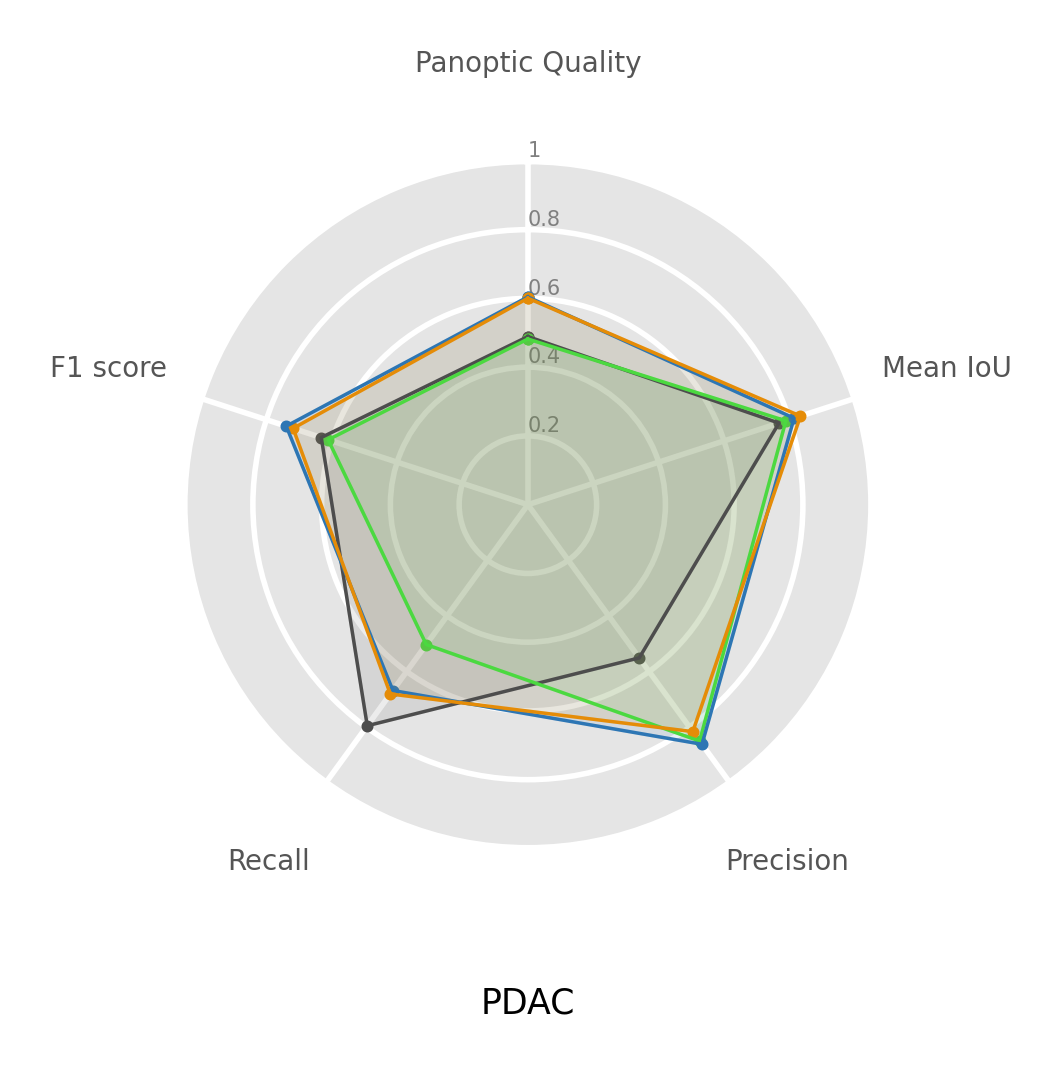

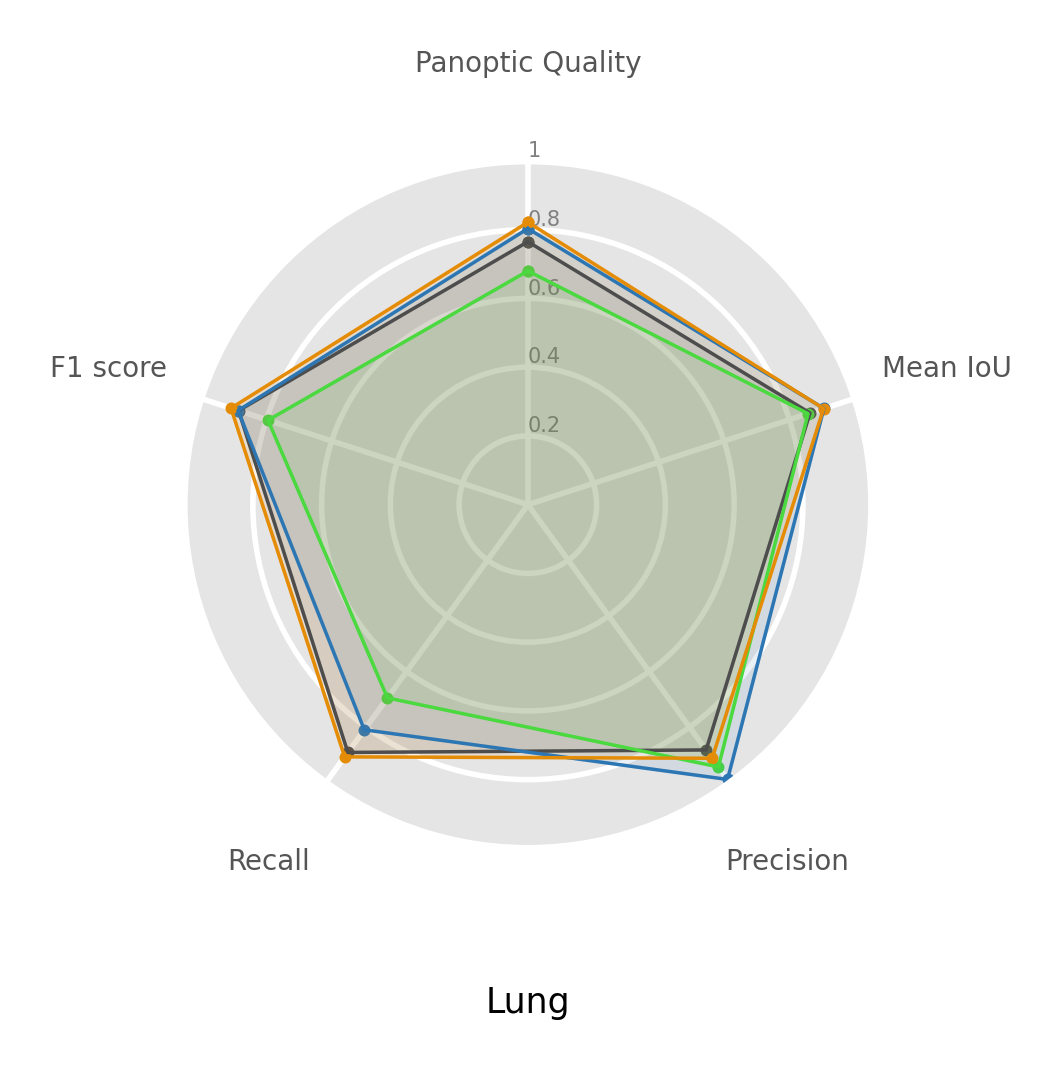

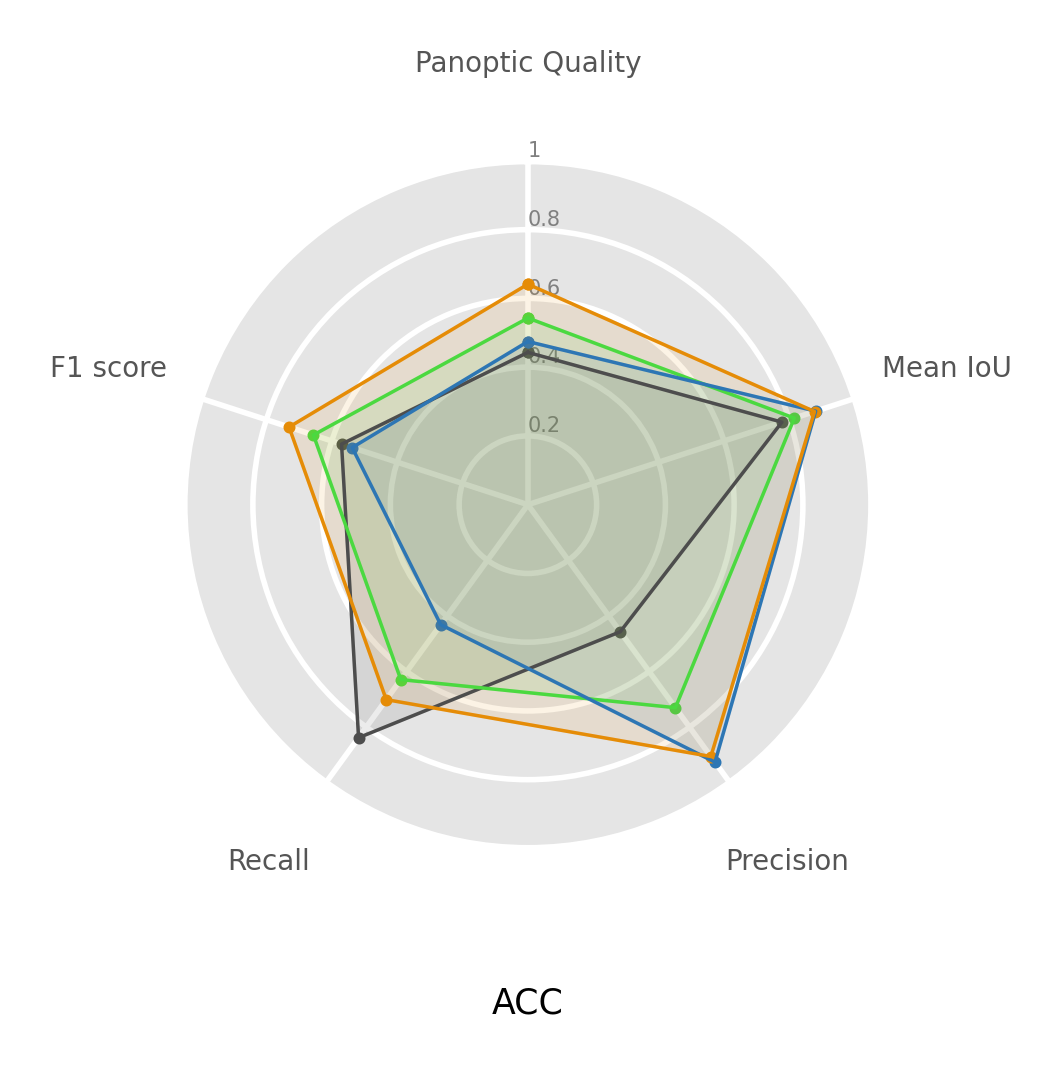

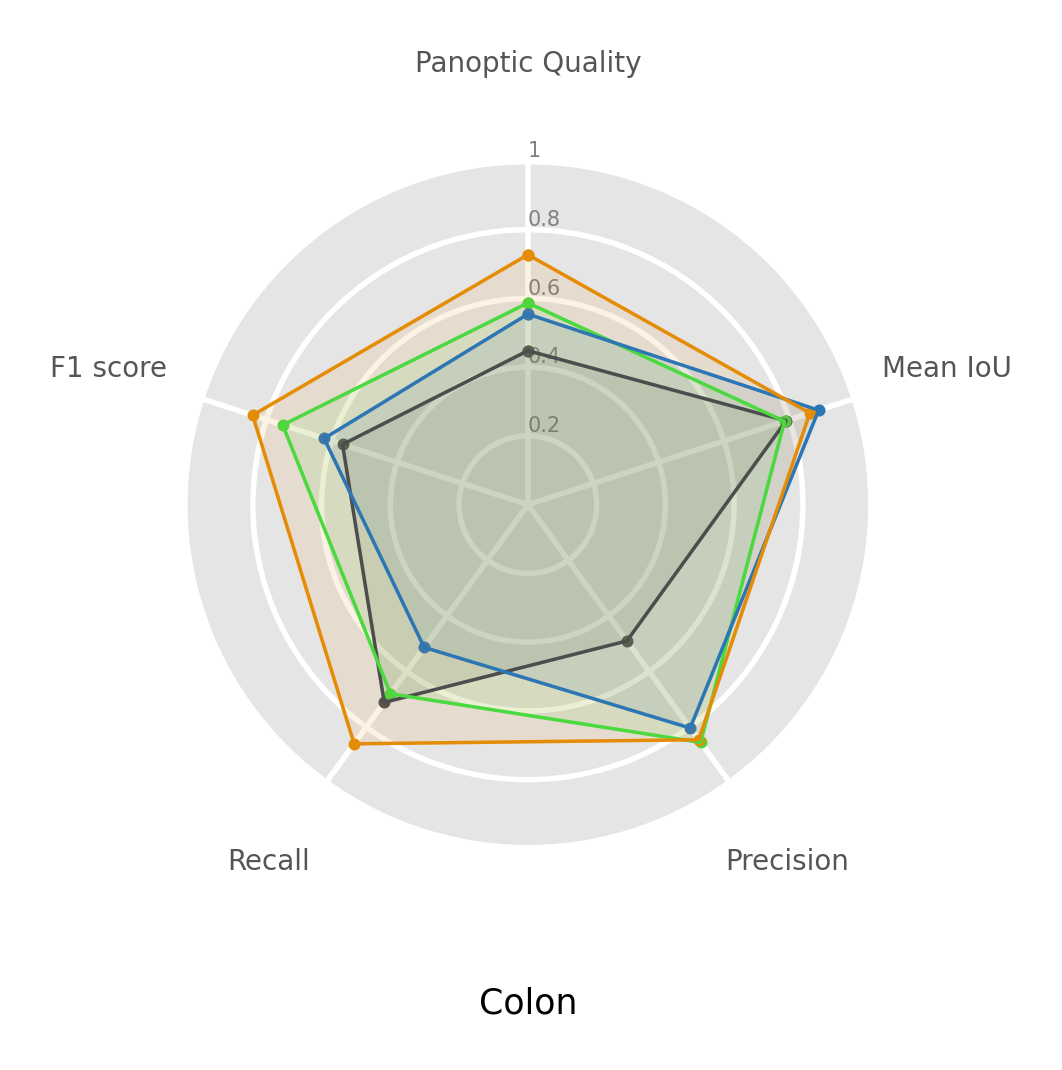

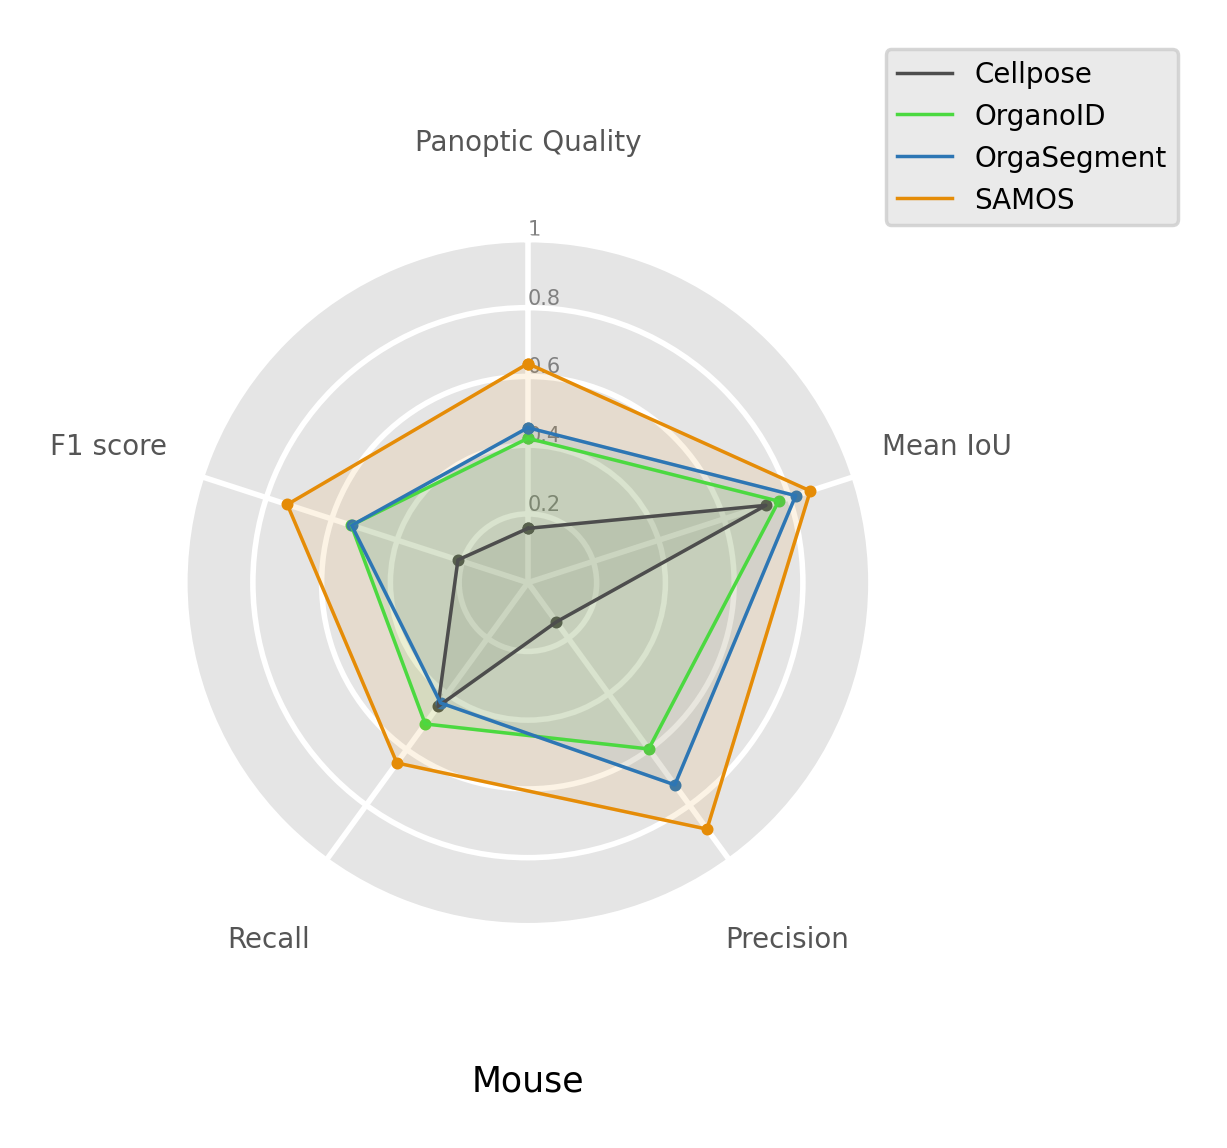

In [ ]:



# fig, axs = plt.subplots(1, 5, 
#                         figsize=(twocol_width_inch, twocol_width_inch * 0.2), 
#                         dpi=dpi, 
#                         subplot_kw={'projection': 'polar'})

# initialize the figure
# plt.figure(figsize=(twocol_width_inch, twocol_width_inch * 0.4), dpi=dpi)
 
# Create a color palette:
# my_palette = plt.cm.get_cmap("Set2", 5)


# color_map = {
#     'Cellpose': (203/255, 233/255, 157/255),      # Light Green
#     'OrganoID': (135/255, 207/255, 164/255),      # Soft Teal
#     'OrgaSegment': (70/255, 158/255, 180/255),  # Bright Teal
#     'SAMOS': (78/255, 98/255, 171/255)  # Deep Purple
# }

# color_map = {
#     'SAMOS': (203/255, 233/255, 157/255),      # Light Green
#     'OrgaSegment': (135/255, 207/255, 164/255),      # Soft Teal
#     'OrganoID': (70/255, 158/255, 180/255),  # Bright Teal
#     'Cellpose': (78/255, 98/255, 171/255)  # Deep Purple
# }


# color_map = {
#     'Cellpose': (0, 0, 0),
#     'OrganoID': (95/255., 207/255., 84/255.),                # Soft Teal with transparency
#     'OrgaSegment': (60/255., 138/255., 170/255.),        # Bright Teal with transparency
#     'SAMOS': (254/255., 165/255., 9/255.),  # Orange with transparency
# }


color_map = {
    'Cellpose': (0.3, 0.3, 0.3),
    'OrganoID': (75/255., 217/255., 64/255.),                # Soft Teal with transparency
    'OrgaSegment': (45/255., 118/255., 180/255.),        # Bright Teal with transparency
    # 'SAMOS': (254/255., 165/255., 9/255.),  # Orange with transparency
    'SAMOS': (229/255., 140/255., 7/255.),  # Orange with transparency
}

# Loop to plot
# for row in range(0, len(df.index)):
for i, test_set in enumerate(['PDAC', 'Lung', 'ACC', 'Colon', 'Mouse']):
    
    fig, axs = plt.subplots(1, 1, 
                            figsize=(twocol_width_inch / 3 * 2, twocol_width_inch / 3 * 2), 
                            dpi=500, #dpi, 
                            subplot_kw={'projection': 'polar'})
    for j, model in enumerate(['Cellpose', 
                               'OrganoID', 
                               'OrgaSegment', 
                               'SAMOS']):
        row = df_combined.loc[(df_combined.model==model) & (df_combined.test_set == test_set), :]
        row = row.drop(columns=['model', 'test_set'])
        row = row.loc[:, ['PQ', 'Mean IoU', #'Mean Dice', 
                          'Precision', 'Recall', 'F1 score']]
        # print(row)
        # print(row.values.flatten())
        make_spider(row=row, title=test_set, color=color_map[model], label=model, ax=axs) #[i])
    if i == 4:
        plt.legend(loc='lower left', bbox_to_anchor=(1, 1))

    plt.gca().set_position((.25 + 0.2/2, .25 + 0.2/2, 0.3, 0.3))
    plt.savefig(results_dir / 'plots' / f'final_olympic_{test_set}.pdf', format='pdf', dpi=500, transparent=True,)
    plt.savefig(results_dir / 'plots' / f'final_olympic_{test_set}.png', format='png', dpi=500, transparent=True,)

In [7]:
df_combined

,test_set,PQ,Mean IoU,Mean Dice,Precision,Recall,F1 score,model
0,PDAC,0.489000,0.768000,0.864000,0.551000,0.795000,0.632000,Cellpose
1,Lung,0.765000,0.863000,0.923000,0.882000,0.891000,0.885000,Cellpose
2,ACC,0.443000,0.777000,0.869000,0.457000,0.838000,0.570000,Cellpose
3,Colon,0.448000,0.790000,0.877000,0.490000,0.711000,0.567000,Cellpose
4,Mouse,0.158000,0.728000,0.833000,0.141000,0.445000,0.214000,Cellpose
0,PDAC,0.482000,0.789000,0.878000,0.850000,0.503000,0.611000,OrganoID
1,Lung,0.680000,0.857000,0.920000,0.943000,0.695000,0.795000,OrganoID
2,ACC,0.543000,0.815000,0.895000,0.730000,0.629000,0.656000,OrganoID
3,Colon,0.587000,0.785000,0.876000,0.855000,0.680000,0.750000,OrganoID
4,Mouse,0.420000,0.767000,0.863000,0.598000,0.508000,0.540000,OrganoID


In [11]:
print(df_combined.set_index(['test_set', 'model']).sort_index().to_latex(float_format="%.3f"))

\begin{tabular}{llrrrrrr}
\toprule
 &  & PQ & Mean IoU & Mean Dice & Precision & Recall & F1 score \\
test_set & model &  &  &  &  &  &  \\
\midrule
\multirow[t]{4}{*}{ACC} & Cellpose & 0.443 & 0.777 & 0.869 & 0.457 & 0.838 & 0.570 \\
 & OrgaSegment & 0.475 & 0.880 & 0.935 & 0.926 & 0.431 & 0.537 \\
 & OrganoID & 0.543 & 0.815 & 0.895 & 0.730 & 0.629 & 0.656 \\
 & SAMOS & 0.641 & 0.877 & 0.932 & 0.906 & 0.701 & 0.731 \\
\cline{1-8}
\multirow[t]{4}{*}{Colon} & Cellpose & 0.448 & 0.790 & 0.877 & 0.490 & 0.711 & 0.567 \\
 & OrgaSegment & 0.554 & 0.889 & 0.941 & 0.803 & 0.513 & 0.623 \\
 & OrganoID & 0.587 & 0.785 & 0.876 & 0.855 & 0.680 & 0.750 \\
 & SAMOS & 0.727 & 0.862 & 0.922 & 0.845 & 0.860 & 0.842 \\
\cline{1-8}
\multirow[t]{4}{*}{Lung} & Cellpose & 0.765 & 0.863 & 0.923 & 0.882 & 0.891 & 0.885 \\
 & OrgaSegment & 0.803 & 0.905 & 0.950 & 0.988 & 0.809 & 0.886 \\
 & OrganoID & 0.680 & 0.857 & 0.920 & 0.943 & 0.695 & 0.795 \\
 & SAMOS & 0.822 & 0.905 & 0.947 & 0.912 & 0.907 & 0.908 \\

# Bar plot - overall results

In [3]:
table = pd.read_csv(results_dir / 'organoID_test_pretraining_correct_conf_thres_aggregated.csv')
table = table[table.metric_type=='segmentation']
table = table[table.model_name.isin(['no_pretraining_best', 'NeurIPS_best', 'OI_best', 'OI_and_NeurIPS_best'])]

table = table.replace({
    'no_pretraining_best': 'no pretraining', 
    'NeurIPS_best': 'NeurIPS', 
    'OI_best': 'Open Images', 
    'OI_and_NeurIPS_best': 'OI + NeurIPS',
    'OrganoID_test': 'PDAC', 
    'OrganoID_test_Lung': 'Lung', 
    'OrganoID_test_ACC': 'ACC', 
    'OrganoID_test_C': 'Colon', 
    'OrganoID_test_mouse': 'Mouse'
})

table = table.pivot(
    index='model_name', columns='testset', values='pq_mean'
)
table

testset,ACC,Colon,Lung,Mouse,PDAC
model_name,,,,,
NeurIPS,0.599217,0.550276,0.793978,0.516579,0.513010
OI + NeurIPS,0.638301,0.606191,0.808124,0.600032,0.545848
Open Images,0.618009,0.555269,0.791746,0.542728,0.500034
no pretraining,0.578035,0.558302,0.793913,0.532769,0.513046


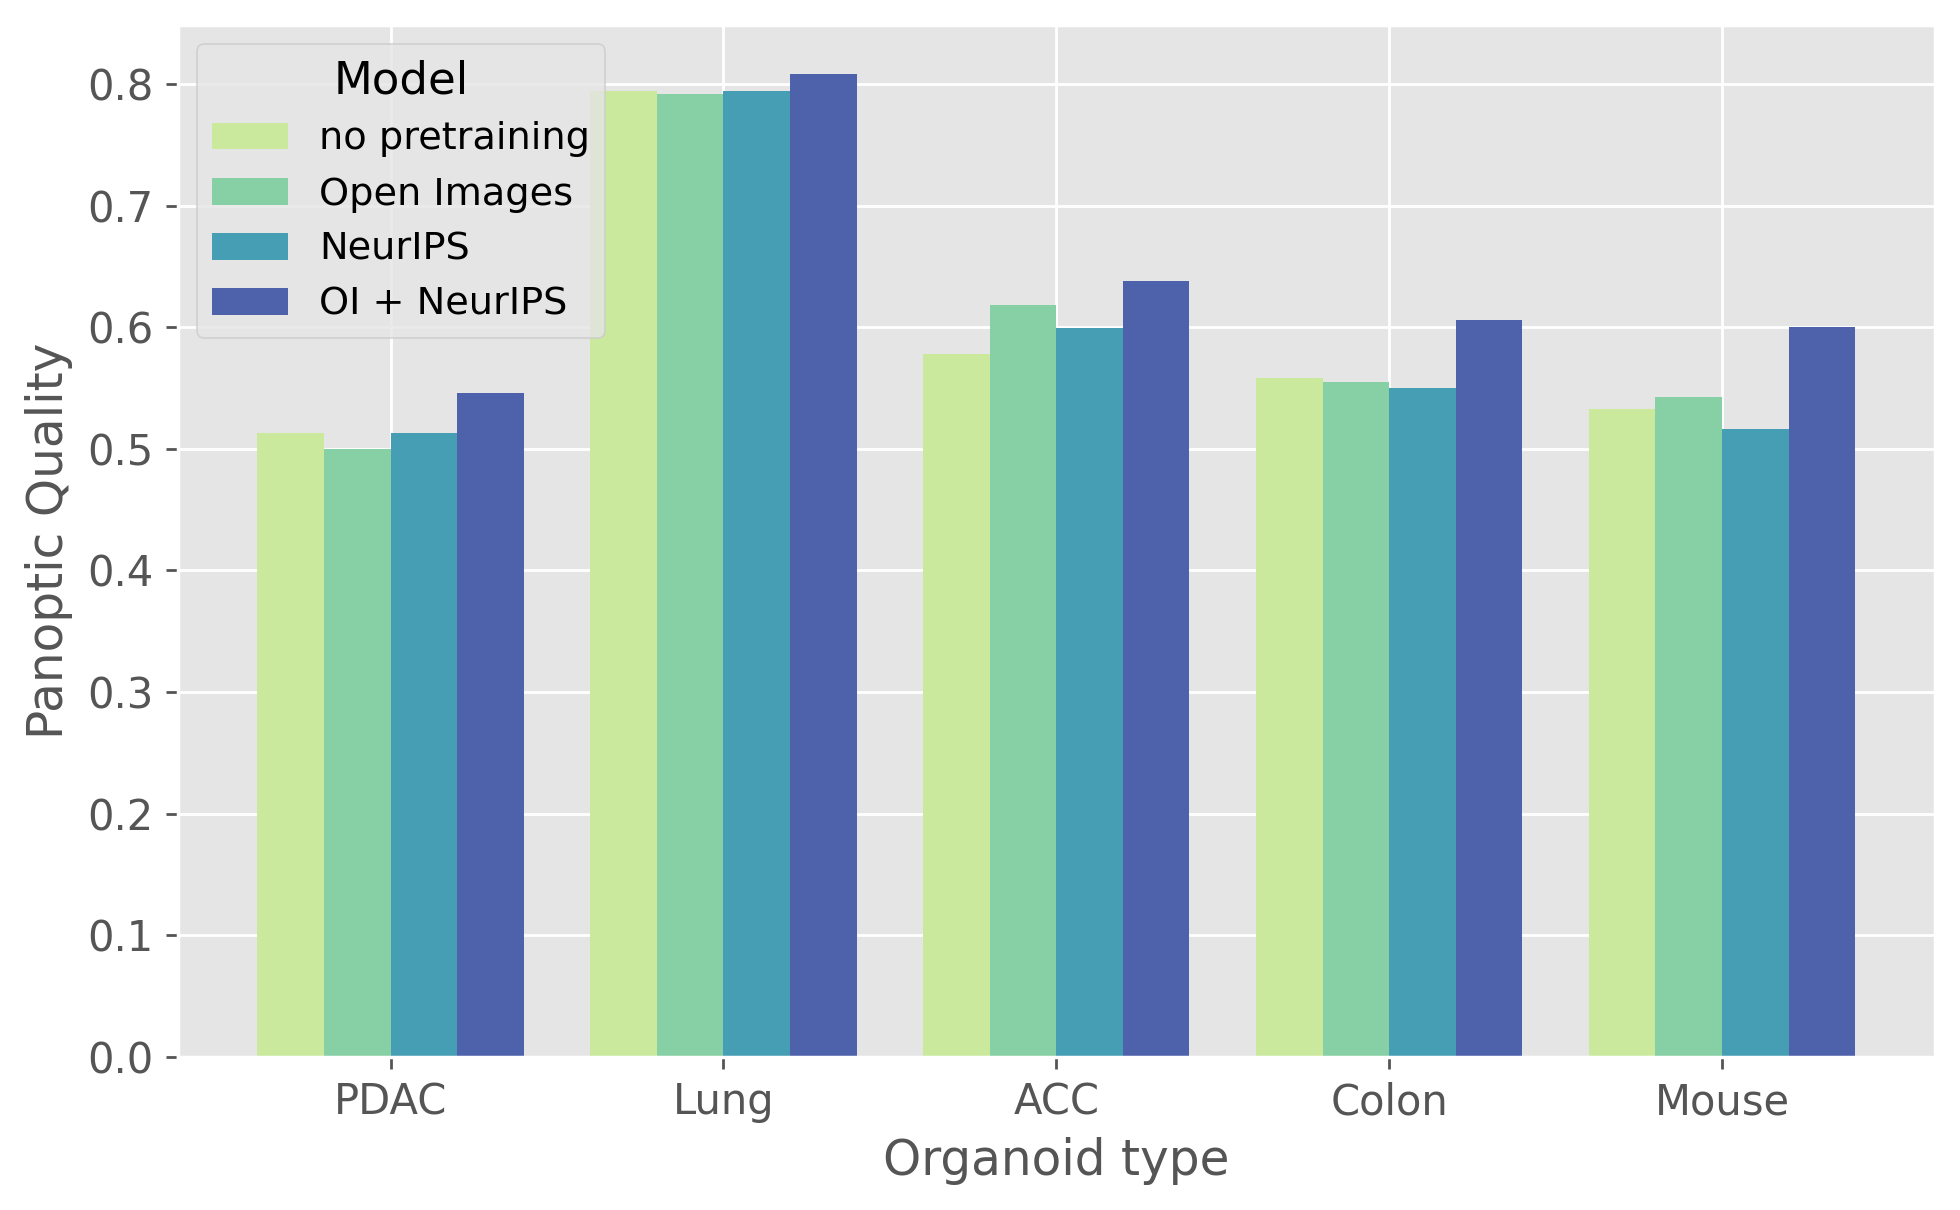

In [5]:

# # Load the Excel file
# file_path = 'organoid_metric_comparison.xlsx'
# table = pd.read_excel(file_path)

# # Extract PQ values for each model and organoid type
# pq_values = table[['Unnamed: 0', 'PQ']].dropna()
# pq_values.columns = ['Model', 'PQ']


dpi=250
matplotlib.rcParams['figure.dpi'] = dpi
matplotlib.rcParams['font.size'] = 4

# Define organoid types and models
organoid_types = ['PDAC', 'Lung', 'ACC', 'Colon', 'Mouse']
models = ['no pretraining', 'Open Images', 'NeurIPS', 'OI + NeurIPS']

# Extract PQ values for each model and organoid type
# pq_values_by_type = {organoid: table[models, organoid].values 
#                      for organoid in organoid_types}

# Bar width and x-axis positions
bar_width = 0.2
x = np.arange(len(organoid_types))

# Define color map
color_map = {
    'no pretraining': (203/255, 233/255, 157/255),      # Light Green
    'Open Images': (135/255, 207/255, 164/255),      # Soft Teal
    'NeurIPS': (70/255, 158/255, 180/255),  # Bright Teal
    'OI + NeurIPS': (78/255, 98/255, 171/255)  # Deep Purple
}

# Set global font sizes
plt.rcParams['font.size'] = 12         
plt.rcParams['axes.labelsize'] = 14     
plt.rcParams['xtick.labelsize'] = 12    
plt.rcParams['ytick.labelsize'] = 12    
plt.rcParams['legend.fontsize'] = 11    
plt.rcParams['legend.title_fontsize'] = 13  

# Plotting
plt.figure(figsize=(8, 5))

# Plot each model's bars with an offset for each organoid type
for i, model in enumerate(models):
    # pq_values = [pq_values_by_type[organoid][i] for organoid in organoid_types]
    pq_values = table.loc[model, organoid_types].values
    plt.bar(x + i * bar_width, pq_values, bar_width, label=model, color=color_map[model])

# Labeling and legend
plt.xlabel('Organoid type', fontsize=14)
plt.ylabel('Panoptic Quality', fontsize=14)
plt.xticks(x + bar_width * 1.5, organoid_types)  # Adjust x-ticks to align with bars
plt.legend(title='Model')
plt.tight_layout()

# Save the plot as PDF
(results_dir / 'plots').mkdir(exist_ok=True)
plt.savefig(results_dir / 'plots' / 'ablation_pretraining_pq_values_final_plot.pdf', format='pdf', dpi=300)
plt.savefig(results_dir / 'plots' / 'ablation_pretraining_pq_values_final_plot.png', format='png', dpi=300)

# Display the plot
plt.show()


In [ ]:
import matplotlib

experiment_name = 'pretraining_final_plot'

plt.style.use('ggplot')

base_datadir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/original_data/')
results_dir = Path('/ictstr01/groups/shared/users/lion.gleiter/organoid_sam/results')

col_width_inch = 3.25
twocol_width_inch = 6.875

dpi=250
matplotlib.rcParams['figure.dpi'] = dpi
matplotlib.rcParams['font.size'] = 4

def plot_metric(table, metric='pq_mean', ylabel='Panoptic Quality'):
    table = table[table.metric_type=='segmentation']
    table = table[table.model_name.isin(['dataset_0', 'dataset_2', 'dataset_5', 'dataset_10', 'dataset_20'])]

    table = table.replace({
        'dataset_0': '0 % SAMOS data', 
        'dataset_2': '2 % SAMOS data', 
        'dataset_5': '5 % SAMOS data', 
        'dataset_10': '10 % SAMOS data', 
        'dataset_20': '20 % SAMOS data',
        'OrganoID_test': 'PDAC', 
        'OrganoID_test_Lung': 'Lung', 
        'OrganoID_test_ACC': 'ACC', 
        'OrganoID_test_C': 'Colon', 
        'OrganoID_test_mouse': 'Mouse'
    })

    table = table.pivot(
        index='model_name', columns='testset', values=metric
    ).loc[['0 % SAMOS data', '2 % SAMOS data', '5 % SAMOS data', '10 % SAMOS data', '20 % SAMOS data'], :]

    
    # Define organoid types and models
    organoid_types = ['PDAC', 'Lung', 'ACC', 'Colon', 'Mouse']
    models = ['0 % SAMOS data', '2 % SAMOS data', '5 % SAMOS data', '10 % SAMOS data', '20 % SAMOS data']

    # Extract PQ values for each model and organoid type
    # pq_values_by_type = {organoid: table[models, organoid].values 
    #                      for organoid in organoid_types}

    # Bar width and x-axis positions
    bar_width = 0.18
    x = np.arange(len(organoid_types))

    # Define color map
    color_map = {
        '0 % SAMOS data': (203/255, 233/255, 157/255),      # Light Green
        '2 % SAMOS data': (135/255, 207/255, 164/255),      # Soft Teal
        '5 % SAMOS data': (70/255, 158/255, 180/255),  # Bright Teal
        '10 % SAMOS data': (78/255, 98/255, 171/255),  # Deep Purple
        '20 % SAMOS data': (80/255, 80/255, 80/255),  # Dark Grey
    }

    # Set global font sizes
    plt.rcParams['font.size'] = 12         
    plt.rcParams['axes.labelsize'] = 14     
    plt.rcParams['xtick.labelsize'] = 12    
    plt.rcParams['ytick.labelsize'] = 12    
    plt.rcParams['legend.fontsize'] = 11    
    plt.rcParams['legend.title_fontsize'] = 13  

    # Plotting
    plt.figure(figsize=(8, 5))

    # Plot each model's bars with an offset for each organoid type
    for i, model in enumerate(models):
        # pq_values = [pq_values_by_type[organoid][i] for organoid in organoid_types]
        pq_values = table.loc[model, organoid_types].values
        plt.bar(x + i * bar_width, pq_values, bar_width, label=model, color=color_map[model])

    # Labeling and legend
    plt.xlabel('Organoid type', fontsize=14)
    plt.ylabel(ylabel, fontsize=14)
    plt.xticks(x + bar_width * 2.0, organoid_types)  # Adjust x-ticks to align with bars
    plt.legend(title='Training set', loc='lower right')
    plt.tight_layout()

    # Save the plot as PDF
    (results_dir / 'plots').mkdir(exist_ok=True)
    plt.savefig(results_dir / 'plots' / f'ablation_{experiment_name}_{metric}.pdf', format='pdf', dpi=300)
    plt.savefig(results_dir / 'plots' / f'ablation_{experiment_name}_{metric}.png', format='png', dpi=300)

    # Display the plot
    plt.show()


# Radar plot - ablation study: one-stage vs two-stage on PDAC

In [ ]:
!pip uninstall kaleido


In [8]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Define color map with RGBA format as strings
color_map = {
    'SAM + DH (no pretraining)': 'rgba(254, 165, 9, 0.2)',  # Orange with transparency
    'OrganoID': 'rgba(135, 207, 164, 0.2)',                # Soft Teal with transparency
    'SAM + DH (public)': 'rgba(70, 158, 180, 0.2)',        # Bright Teal with transparency
}

# Load the metrics values from the specified file
file_path_txt = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\datasets\organoID_test\PDAC\scratch_metrics_values_one\overall_metrics.txt'

# Function to read the overall metrics from the text file
def read_metrics_from_txt(file_path):
    metrics = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        # Assuming the file has the format: 'MetricName: value'
        for line in lines:
            if ':' in line:
                metric_name, value = line.split(':')
                metrics[metric_name.strip()] = float(value.strip())
    return metrics

# Read the metrics for Model 1: SAM + DH (no pretraining)
metrics_model_1 = read_metrics_from_txt(file_path_txt)

# Extracting metrics values
stats = [
    metrics_model_1.get('mean_pq', 0),                # Adjust the metric names based on your file
    metrics_model_1.get('mean_iou', 0),
    metrics_model_1.get('mean_dice_coefficient', 0),
    metrics_model_1.get('mean_precision', 0),
    metrics_model_1.get('mean_recall', 0),
    metrics_model_1.get('mean_f1_score', 0)
]

# Load the Excel file for Model 2 and Model 3 metrics
file_path_excel = 'organoid_metric_comparison_PDAC.xlsx'
table = pd.read_excel(file_path_excel)

# Extract PQ values for each model
# Adjust column names based on your Excel file structure
model_2_metrics = table[table['Unnamed: 0'] == 'OrganoID'].iloc[0]
model_3_metrics = table[table['Unnamed: 0'] == 'SAM + DH (public)'].iloc[0]

# Extracting metrics values for Model 2 and Model 3
stats2 = [
    model_2_metrics['PQ'],
    model_2_metrics['Mean IoU'],
    model_2_metrics['Mean Dice'],
    model_2_metrics['Precision'],
    model_2_metrics['Recall'],
    model_2_metrics['F1 Score']
]

stats3 = [
    model_3_metrics['PQ'],
    model_3_metrics['Mean IoU'],
    model_3_metrics['Mean Dice'],
    model_3_metrics['Precision'],
    model_3_metrics['Recall'],
    model_3_metrics['F1 Score']
]

# Example data labels
labels = np.array(['PQ', 'Mean IoU', 'Mean Dice', 'Precision', 'Recall', 'F1 Score'])

# Number of variables
num_vars = len(labels)

# Create a figure
fig = go.Figure()

# Add the first model's radar plot
fig.add_trace(go.Scatterpolar(
    r=stats + [stats[0]],  # Loop back to the start
    theta=labels.tolist() + [labels[0]],  # Loop back to the start
    fill='toself',
    name='SAM + DH (no pretraining)',
    line_color=color_map['SAM + DH (no pretraining)'].replace('0.2', '1'),  # Opaque line color
    fillcolor=color_map['SAM + DH (no pretraining)']
))

# Add the second model's radar plot
fig.add_trace(go.Scatterpolar(
    r=stats2 + [stats2[0]],  # Loop back to the start
    theta=labels.tolist() + [labels[0]],  # Loop back to the start
    fill='toself',
    name='OrganoID',
    line_color=color_map['OrganoID'].replace('0.2', '1'),  # Opaque line color
    fillcolor=color_map['OrganoID']
))

# Add the third model's radar plot
fig.add_trace(go.Scatterpolar(
    r=stats3 + [stats3[0]],  # Loop back to the start
    theta=labels.tolist() + [labels[0]],  # Loop back to the start
    fill='toself',
    name='SAM + DH (public)',
    line_color=color_map['SAM + DH (public)'].replace('0.2', '1'),  # Opaque line color
    fillcolor=color_map['SAM + DH (public)']
))

front_size = 12
# Update layout with font size adjustments
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],  # Adjust the range if necessary based on your data
            tickfont=dict(size=front_size),  # Adjust radial axis tick font size
            titlefont=dict(size=front_size)  # Adjust radial axis title font size if needed
        ),
        angularaxis=dict(
            tickfont=dict(size=front_size)  # Adjust angular axis (labels) font size
        )
    ),
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="bottom",
        y=1.1,
        xanchor="center",
        x=0.5,
        font=dict(size=front_size)  # Adjust legend font size
    ),
    template="plotly",
    title=dict(
        #text='Model Performance Comparison Across PDAC',  # Add or update the title if needed
        font=dict(size=front_size)  # Adjust title font size
    )
)

# Show the figure
fig.show()


# Radar plot - ablation study: add private data

In [9]:
import plotly.graph_objects as go
import numpy as np
import pandas as pd

# Define color map with RGBA format as strings
color_map = {
    'SAM + DH (public)': 'rgba(70, 158, 180, 0.2)',        # Bright Teal with transparency
    'SAM + DH (public + private)': 'rgba(78, 98, 171, 0.2)', # Deep Purple with transparency
}

# Load the metrics values from the specified file
file_path_txt_pub = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\datasets\own_organoid\test\scratch_metrics_values_pub\overall_metrics.txt'

file_path_txt_com = r'C:\Users\ZHY\PycharmProjects\SAM_with_Detection_Head\datasets\own_organoid\test\scratch_metrics_values_com\overall_metrics.txt'

# Function to read the overall metrics from the text file
def read_metrics_from_txt(file_path):
    metrics = {}
    with open(file_path, 'r') as file:
        lines = file.readlines()
        # Assuming the file has the format: 'MetricName: value'
        for line in lines:
            if ':' in line:
                metric_name, value = line.split(':')
                metrics[metric_name.strip()] = float(value.strip())
    return metrics

# Read the metrics for Model 1: SAM + DH (no pretraining)
metrics_model_1 = read_metrics_from_txt(file_path_txt_pub)
metrics_model_2 = read_metrics_from_txt(file_path_txt_com)

# Extracting metrics values
stats = [
    metrics_model_1.get('mean_pq', 0),                # Adjust the metric names based on your file
    metrics_model_1.get('mean_iou', 0),
    metrics_model_1.get('mean_dice_coefficient', 0),
    metrics_model_1.get('mean_precision', 0),
    metrics_model_1.get('mean_recall', 0),
    metrics_model_1.get('mean_f1_score', 0)
]

stats2 = [
    metrics_model_2.get('mean_pq', 0),                # Adjust the metric names based on your file
    metrics_model_2.get('mean_iou', 0),
    metrics_model_2.get('mean_dice_coefficient', 0),
    metrics_model_2.get('mean_precision', 0),
    metrics_model_2.get('mean_recall', 0),
    metrics_model_2.get('mean_f1_score', 0)
]

# Example data labels
labels = np.array(['PQ', 'Mean IoU', 'Mean Dice', 'Precision', 'Recall', 'F1 Score'])

# Number of variables
num_vars = len(labels)

# Create a figure
fig = go.Figure()

# Add the first model's radar plot
fig.add_trace(go.Scatterpolar(
    r=stats + [stats[0]],  # Loop back to the start
    theta=labels.tolist() + [labels[0]],  # Loop back to the start
    fill='toself',
    name='SAM + DH (public)',
    line_color=color_map['SAM + DH (public)'].replace('0.2', '1'),  # Opaque line color
    fillcolor=color_map['SAM + DH (public)']
))

# Add the second model's radar plot
fig.add_trace(go.Scatterpolar(
    r=stats2 + [stats2[0]],  # Loop back to the start
    theta=labels.tolist() + [labels[0]],  # Loop back to the start
    fill='toself',
    name='SAM + DH (public + private)',
    line_color=color_map['SAM + DH (public + private)'].replace('0.2', '1'),  # Opaque line color
    fillcolor=color_map['SAM + DH (public + private)']
))

front_size = 12
# Update layout with font size adjustments
fig.update_layout(
    polar=dict(
        radialaxis=dict(
            visible=True,
            range=[0, 1],  # Adjust the range if necessary based on your data
            tickfont=dict(size=front_size),  # Adjust radial axis tick font size
            titlefont=dict(size=front_size)  # Adjust radial axis title font size if needed
        ),
        angularaxis=dict(
            tickfont=dict(size=front_size)  # Adjust angular axis (labels) font size
        )
    ),
    showlegend=True,
    legend=dict(
        orientation="v",
        yanchor="bottom",
        y=1.1,
        xanchor="center",
        x=0.5,
        font=dict(size=front_size)  # Adjust legend font size
    ),
    template="plotly",
    title=dict(
        #text='Model Performance Comparison Across PDAC',  # Add or update the title if needed
        font=dict(size=front_size)  # Adjust title font size
    )
)

# Show the figure
fig.show()
